# Анализ датасета

In [ ]:
import json

def load_json(path):
    with open(path, 'r', encoding='utf8') as file:
        return json.load(file)

In [ ]:
data = load_json("all_texts.json")

Анализ тестовых данных

In [ ]:
lens = [len(x['text'].split()) for x in data]

max_l, min_l, mean_l = max(lens), min(lens), sum(lens)/len(lens)

print(f'Минимальная длина текста: {min_l}')
print(f'Максимальная длина текста: {max_l}')
print(f'Средняя длина текста: {mean_l:.3f}')

Минимальная длина текста: 4
Максимальная длина текста: 117
Средняя длина текста: 26.930


<BarContainer object of 67 artists>

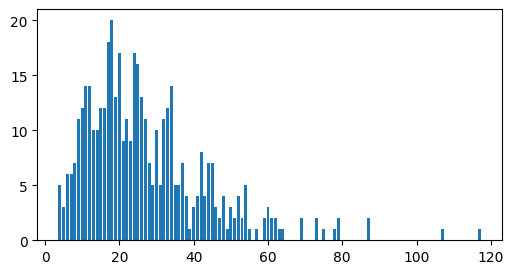

In [ ]:
from collections import Counter
from matplotlib import pyplot as plt

len_counts = Counter(lens)
plt.figure(figsize = (6,3))
plt.bar(len_counts.keys(), len_counts.values())

Вывод самого длинного текста.

In [ ]:
for elem in data:
    if len(elem['text'].split()) == max_l:
        print(elem['sent_id'])
        print(elem['text'])

225
Romero, who grew up in the working-class, Latino and industrial city of Hialeah, Florida, says: “I don’t remember a bookstore. I had the library in Miami Springs across the bridge but in Hialeah around us, what was in walking distance because we didn’t have a car, was the Publix [supermarket] and sometimes we would get books from Goodwill [thrift store] as well. “They had that democratic aspect to them where you can just find them anywhere and it always felt like it was the pick ’n’ mix candy-type store where there is something here for everyone, whether it’s the Harlequin romance novel or something very pulpy like a sci-fi or horror novel that you could quickly get.”


Определение количества текстов, состоящих более чем из одного предложения.

In [ ]:
count = 0
for elem in data:
    text = elem['text']
    if '\n' in text or '.' in text[:-1]:
        count+=1
print(count)

70


Преобразование наших данных в датафрейм.

In [ ]:
opinions = []
for elem in data:
    for op in elem['opinions']:
        # источник и интервал
        if len(op['Source'][0]) > 1:
            source_text = op['Source'][0]
            source_span = op['Source'][1]
        else:
            source_text = op['Source'][0][0]
            source_span = op['Source'][1][0]
        # объект и интервал
        if len(op['Target'][0]) > 1:
            target_text = op['Target'][0]
            target_span = op['Target'][1]
        else:
            target_text = op['Target'][0][0]
            target_span = op['Target'][1][0]
        # выражение и интервал
        if len(op['Polar_expression'][0]) > 1:
            exp_text = op['Polar_expression'][0]
            exp_span = op['Polar_expression'][1]
        else:
            exp_text = op['Polar_expression'][0][0]
            exp_span = op['Polar_expression'][1][0]
        opinions.append([elem['sent_id'], elem['text'], source_text, target_text, exp_text,
                       op['Polarity'], source_span, target_span, exp_span, elem['tag']])

In [ ]:
import pandas as pd
cols = ['sent_id', 'text', 'Source', 'Target', 'Polar_expression', 'Polarity', 'Source_span', 'Target_span', 'Polar_expression_span', "tag"]
df = pd.DataFrame(opinions, columns = cols)
df

,sent_id,text,Source,Target,Polar_expression,Polarity,Source_span,Target_span,Polar_expression_span,tag
0,1,"These days, a doomsday bunker (or, in Elon Mus...",any self-respecting billionaire,a doomsday bunker,is de rigueur,POS,98:129,12:29,80:93,culture
1,2,A slew of recent dramas suggests that we are f...,we,underground real estate,are fascinated by such impressive,POS,38:40,75:98,41:74,culture
2,3,"Most audacious is Paradise on Disney+, in whic...",AUTHOR,Paradise on Disney+,Most audacious is,POS,NULL,18:37,0:17,culture
3,3,"Most audacious is Paradise on Disney+, in whic...",AUTHOR,building project,staggeringly elaborate,POS,NULL,134:150,111:133,culture
4,4,On the surface at least – no pun intended – it...,NULL,Fallout,hugely popular,POS,0:0,126:133,96:110,culture
...,...,...,...,...,...,...,...,...,...,...
364,441,It is an uncomfortable truth that inclusion wi...,AUTHOR,inclusion,"[uncomfortable truth, jarring and emotionally ...",NEG,NULL,34:43,"[6:28, 52:88]",politics
365,442,That this has concerned such a slur has been d...,AUTHOR,That this has concerned such a slur,deeply unfortunate,NEG,NULL,0:35,45:63,politics
366,443,What I cannot countenance is the BBC's decisio...,AUTHOR,the BBC's decision not to edit out,cannot countenance,NEG,NULL,29:62,7:25,politics
367,444,"I left the room with a sense of understanding,...",AUTHOR,the incident,a little unsettled,NEG,NULL,84:96,61:79,politics


Распределение тэгов.

tag
politics    170
culture     135
science      64
Name: count, dtype: int64


<Axes: xlabel='tag'>

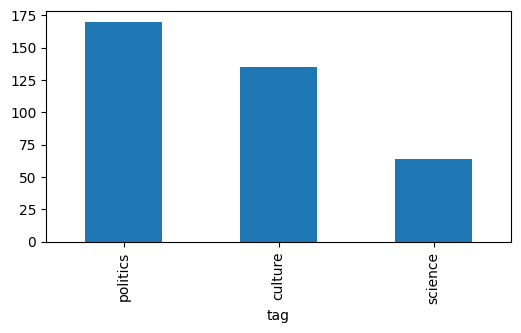

In [ ]:
print(df['tag'].value_counts())

plt.figure(figsize = (6,3))
df['tag'].value_counts().plot.bar()

Оценка распределения классов тональности.

Polarity
NEG    211
POS    158
Name: count, dtype: int64


<Axes: xlabel='Polarity'>

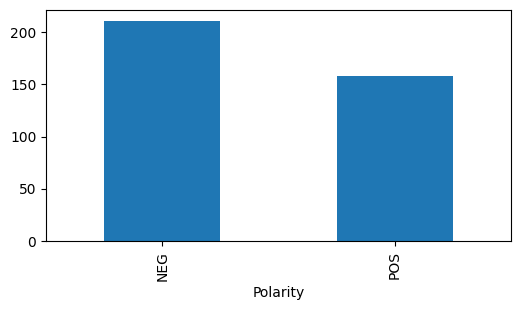

In [ ]:
print(df['Polarity'].value_counts())

plt.figure(figsize = (6,3))
df['Polarity'].value_counts().plot.bar()

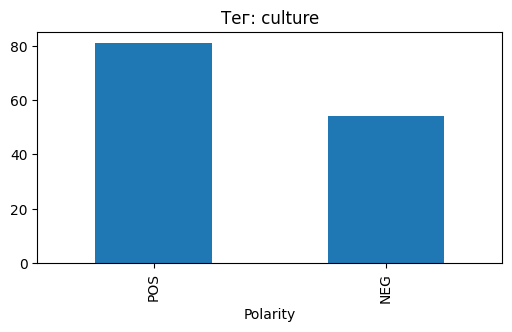

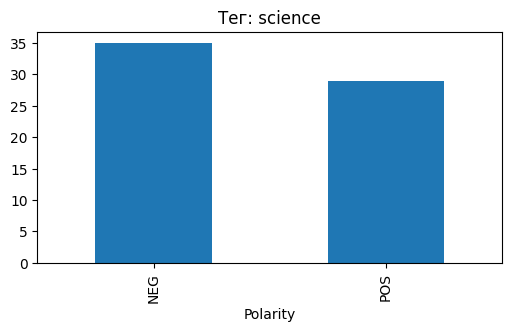

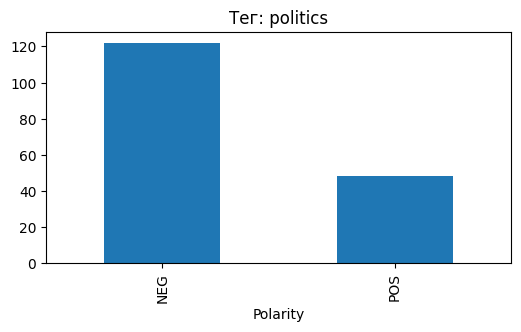

In [ ]:
selected_tags = ['culture', 'science', 'politics']
for tag in selected_tags:
    subset = df[df['tag'] == tag]
    plt.figure(figsize=(6,3))
    subset['Polarity'].value_counts().plot.bar()
    plt.title(f'Тег: {tag}')
    plt.show()

Тексты с множественными мнениями: распределение на графике.

In [ ]:
textcount = Counter(df['text'].value_counts())
textcount

Counter({5: 1, 4: 3, 3: 11, 2: 65, 1: 189})

<BarContainer object of 5 artists>

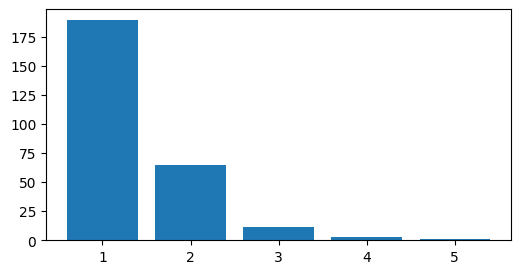

In [ ]:
plt.figure(figsize = (6,3))
plt.bar(textcount.keys(), textcount.values())

Подсчёт максимальной и средней длины для источника, объекта и выражения (с примерами)

In [ ]:
sources = []
for item in df['Source']:
    if isinstance(item, str):
        sources.append(item)
    else:
        sources+=item
max_s = max([len(x.split()) for x in sources])
mean_s = sum([len(x.split()) for x in sources])/len(sources)
print(f'Максимальная длина источника: {max_s}')
print(f'Средняя длина источника: {mean_s:.3f}')

print(f'Самый длинный источник:')
for item in df['Source']:
    if isinstance(item, str) and len(item.split()) == max_s:
        print(f'"{item}"')

Максимальная длина источника: 7
Средняя длина источника: 1.414
Самый длинный источник:
"Damon Albarn and Jamie Hewlett’s cartoon band"


In [ ]:
targets = []
for item in df['Target']:
    if isinstance(item, str):
        targets.append(item)
    else:
        targets+=item
max_t = max([len(x.split()) for x in targets])
mean_t = sum([len(x.split()) for x in targets])/len(targets)
print(f'Максимальная длина объекта: {max_t}')
print(f'Средняя длина объекта: {mean_t:.3f}')

for item in df['Target']:
    if isinstance(item, str) and len(item.split()) == max_t:
        print(f'Самый длинный объект:\n"{item}"')

Максимальная длина объекта: 45
Средняя длина объекта: 4.016
Самый длинный объект:
"Across the Organisation for Economic Co-operation and Development, there is housing insecurity, with half of adults in their 20s living with their parents. Education debt is growing exponentially, and last week the UK unveiled the highest figures for youth unemployment in more than a decade."


In [ ]:
expressions = list()
for item in df['Polar_expression']:
    if isinstance(item, str):
        expressions.append(item)
    else:
        expressions+=item
max_e = max([len(x.split()) for x in expressions])
mean_e = sum([len(x.split()) for x in expressions])/len(expressions)
print(f'Максимальная длина выражения: {max_e}')
print(f'Средняя длина выражения: {mean_e:.3f}')

for item in df['Polar_expression']:
    if isinstance(item, str) and len(item.split()) == max_e:
        print(f'Самое длинное выражение:\n"{item}"')

Максимальная длина выражения: 48
Средняя длина выражения: 4.176
Самое длинное выражение:
"more consistent – more like an album, less like a playlist constructed by someone with impressively wide-ranging taste – than its immediate predecessors: something you’re more likely to listen to from start to finish than play with your finger ready to click fast-forward, panning for the best bits"


Самые частые источники

In [ ]:
df['Source'].value_counts()

,count
Source,
AUTHOR,204
NULL,28
he,5
she,4
Woolfson,4
...,...
Star Sports,1
other half,1
Farage-fans,1


Количество разрывных и множественных источников, объектов и выражений (с примерами)

In [ ]:
s, t, e = 0, 0, 0
for i, row in df.iterrows():
    if isinstance(row['Source'], list):
        s+=1
    if isinstance(row['Target'], list):
        t+=1
    if isinstance(row['Polar_expression'], list):
        e+=1

print(f'Множественный/ фрагментированный источник: {s}')
print(f'Множественный/ фрагментированный объект: {t}')
print(f'Множественное/ фрагментированное выражение: {e}')

Множественный/ фрагментированный источник: 1
Множественный/ фрагментированный объект: 8
Множественное/ фрагментированное выражение: 42


In [ ]:
for i, row in df.iterrows():
    if isinstance(row['Polar_expression'], list):
        print(row['Polar_expression'], row['Polar_expression_span'], sep = '\n')

['turns out to be based on deception', 'It’s an illusion, and it’s not even giving us what it promised.']
['59:93', '187:250']
['The most terrifying character in Paradise', 'ruthless']
['0:41', '123:131']
['He started crying', 'He was physically walking up this thing that he had imagined years earlier']
['84:101', '124:198']
['career peak', 'glowing with life']
['39:50', '73:90']
['seldom concise affairs', 'of variable quality', 'tricky to navigate']
['20:42', '51:70', '77:95']
['wistful, descending melodies', 'liberally decorated']
['72:100', '106:125']
['trying a bit too hard to put a positive spin on things', 'gratingly perky tune being whistled']
['32:86', '203:238']
['big footprint', 'the biggest sitcom on Earth']
['19:31', '86:112']
['Luckily, this feeling vanishes about 15 seconds in', 'is as Scrubsy as it gets']
['328:378', '407:431']
['blame', 'for social ills']
['10:15', '50:65']
['great strengths', 'readiness to blame people']
['11:26', '92:117']
['hate', 'want to reverse']


# Применение больших языковых моделей

## Фью-шот с подбором примеров в зависимости от тематики статьи

In [ ]:
def load_json(path):
    with open(path, 'r', encoding='utf8') as f:
        return json.load(f)


def get_single_value(field):
    if not field or not field[0]:
        return "NULL"
    return field[0][0]


def format_example(entry):
    lines = []
    lines.append("***Text***")
    lines.append(entry["text"])
    lines.append("***Answer***")
    for op in entry.get("opinions", []):
        source = get_single_value(op["Source"])
        target = get_single_value(op["Target"])
        polarity = op["Polarity"]
        polar_expression = get_single_value(op["Polar_expression"])

        lines.append(
            f'Source: "{source}", Target: "{target}", Polarity: "{polarity}", '
            f'Polar_expression: "{polar_expression}".'
        )

    return "\n".join(lines)


categories = ["culture", "science", "politics"]

raw_data_dict = {
    category: load_json(f"{category}_ex.json")
    for category in categories
}

# raw_data_dict = {"culture": load_json(f"{"culture"}_ex.json")}

data_dict = {
    category: [format_example(entry) for entry in entries]
    for category, entries in raw_data_dict.items()
}

In [ ]:
print(data_dict["culture"][0])

***Text***
So convincing is this Truman Show-style facsimile – complete with robo-ducks and a massive lightbulb suspended in the sky – that it’s not until the final moments of the pilot episode that viewers realised where the story was taking place, or what kind of show they were watching.
***Answer***
Source: "AUTHOR", Target: "this Truman Show-style facsimile", Polarity: "POS", Polar_expression: "So convincing is this".


In [ ]:
BASE_PROMPT = (
    "Your task is to analyze a text and extract opinion expressions as opinion tuples. "
    "Each opinion tuple must contain 4 components:\n"
    "1. Source of the opinion: the author, a named entity from the text (a substring of the original text), or \"NULL\". Key = Source;\n"
    "2. Target of the opinion: a named entity from the text (a substring of the original text). Key = Target;\n"
    "3. Polarity: positive or negative (\"POS\" / \"NEG\"). Only \"POS\" and \"NEG\" are allowed; \"NULL\" is not allowed. Key = Polarity;\n"
    "4. Polar expression: the argument on which the final polarity is based "
    "(one or more substrings of the original text). Key = Polar_expression;\n"
    "The values of Source, Target, and Polarity must be enclosed in quotation marks. "
    "If the opinion source is absent, set Source = \"NULL\". If the source is the author, set Source = \"AUTHOR\". "
    "IMPORTANT:"
    "All Source, Target, and Polar_expression MUST be exact substrings of the input text."
    "If a phrase does not appear exactly in the text, DO NOT include it."
    "DO NOT use any information from previous examples."
    "ONLY extract information from the given text."
    "If no valid opinion tuples can be extracted, return an empty list []."
    "Target and Polar_expression must always exactly match substrings of the text and keep the same grammatical form.\n"
    "Do not add any explanations. Return the answer as a JSON list, where each element is an opinion tuple. "
    "Do not output the word json. "
    "Each opinion tuple is a dictionary with four keys: Source, Target, Polarity, Polar_expression.\n"
    "For the extracted Source, Target, Polarity, and Polar_expression, the following statement must be true: "
    "based on Polar_expression, Source has a Polarity relation to Target.\n"
)

In [ ]:
def build_prompt(text, topic, data_dict, n_examples):
    """
    Дополняет промпт нужными примерами, основываясь на data_dict[topic].
    """
    if topic not in data_dict:
        raise KeyError(f"Unknown topic: {topic}. Available topics: {list(data_dict.keys())}")

    examples = data_dict[topic][:n_examples]

    examples_block = "\n\n".join(examples)

    final_prompt = (
        BASE_PROMPT
        + "\n\n"
        + "Below are examples of the task:\n"
        + examples_block
        + "\n\n"
        + "Analyze the following text in the same way.\n"
        + "***Text***\n"
        + text
        + "\n***Answer***\n"
    )
    return final_prompt

### Модель Qwen2.5-7B-Instruct

In [ ]:
!pip install transformers accelerate bitsandbytes

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 15.6 MB/s eta 0:00:00


In [ ]:
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig

model_name = "Qwen/Qwen2.5-7B-Instruct"

# Конфигурация 4‑битной квантизации
quant_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=True
)

tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForCausalLM.from_pretrained(
    model_name,
    quantization_config=quant_config,
    device_map="auto",
    trust_remote_code=True
)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/663 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/339 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/243 [00:00<?, ?B/s]

#### Фью-шот на 5 примерах

In [ ]:
# пример
prompt = build_prompt(
    text="In these shows, though, the deadliest threat invariably comes from within the bunker – sometimes even from within the “nuclear” family at its heart.",
    topic="culture",
    data_dict=data_dict,
    n_examples=5
)

print(prompt)

Your task is to analyze a text and extract opinion expressions as opinion tuples. Each opinion tuple must contain 4 components:
1. Source of the opinion: the author, a named entity from the text (a substring of the original text), or "NULL". Key = Source;
2. Target of the opinion: a named entity from the text (a substring of the original text). Key = Target;
3. Polarity: positive or negative ("POS" / "NEG"). Only "POS" and "NEG" are allowed; "NULL" is not allowed. Key = Polarity;
4. Polar expression: the argument on which the final polarity is based (one or more substrings of the original text). Key = Polar_expression;
The values of Source, Target, and Polarity must be enclosed in quotation marks. If the opinion source is absent, set Source = "NULL". If the source is the author, set Source = "AUTHOR". IMPORTANT:All Source, Target, and Polar_expression MUST be exact substrings of the input text.If a phrase does not appear exactly in the text, DO NOT include it.DO NOT use any information

In [ ]:
def inference(prompt_text):
    messages = [
        {"role": "system", "content": "You are a JSON-only assistant. Your entire response must be a single JSON array, nothing else. You can only extract opinions from a given text. Everything else is strictly prohibited."},
        {"role": "user", "content": prompt_text}
    ]
    text = tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True
    )
    model_inputs = tokenizer([text], return_tensors="pt").to(model.device)

    generated_ids = model.generate(
        **model_inputs,
        max_new_tokens=512
    )
    generated_ids = [
        output_ids[len(input_ids):] for input_ids, output_ids in zip(model_inputs.input_ids, generated_ids)
    ]
    response = tokenizer.batch_decode(generated_ids, skip_special_tokens=True)[0]
    return response.strip()

Применение функции к одному предложению

In [ ]:
sent_id = 0
text = data[sent_id]["text"]

prompt = build_prompt(
    text,
    topic=data[sent_id]["tag"],
    data_dict=data_dict,
    n_examples=5
)

print(f'Prompt:\n{prompt}\n{text}\n')
output = inference(data[sent_id]["text"])
print(f'Predicted tuple: {type(output)}\n{output}\n')
print(f'Gold tuple: {type(data[sent_id]["opinions"])}\n{data[sent_id]["opinions"]}')

Prompt:
Your task is to analyze a text and extract opinion expressions as opinion tuples. Each opinion tuple must contain 4 components:
1. Source of the opinion: the author, a named entity from the text (a substring of the original text), or "NULL". Key = Source;
2. Target of the opinion: a named entity from the text (a substring of the original text). Key = Target;
3. Polarity: positive or negative ("POS" / "NEG"). Only "POS" and "NEG" are allowed; "NULL" is not allowed. Key = Polarity;
4. Polar expression: the argument on which the final polarity is based (one or more substrings of the original text). Key = Polar_expression;
The values of Source, Target, and Polarity must be enclosed in quotation marks. If the opinion source is absent, set Source = "NULL". If the source is the author, set Source = "AUTHOR". IMPORTANT:All Source, Target, and Polar_expression MUST be exact substrings of the input text.If a phrase does not appear exactly in the text, DO NOT include it.DO NOT use any inf

Тестирование на датасете

In [ ]:
from tqdm.auto import tqdm

train_output = []
progress_bar = tqdm(range(len(data)))

for sample in data:
    prompt = build_prompt(
        sample["text"],
        topic=sample["tag"],
        data_dict=data_dict,
        n_examples=5
    )
    sample_output = inference(prompt)   # новая функция
    train_output.append(sample_output)
    progress_bar.update(1)

  0%|          | 0/446 [00:00<?, ?it/s]

In [ ]:
print(train_output[:10])

['[{"Source": "NULL", "Target": "Peter Thiel’s", "Polarity": "POS", "Polar_expression": "described as “mega”"}, {"Source": "NULL", "Target": "New Zealand", "Polarity": "NULL", "Polar_expression": "located in"}]', '[{"Source": "NULL", "Target": "doomsday bunker", "Polarity": "POS", "Polar_expression": "de rigueur"}, {"Source": "NULL", "Target": "billionaire", "Polarity": "NEG", "Polar_expression": "wonder if they know something we don\'t"}]', '[{"Source": "NULL", "Target": "dramas", "Polarity": "POS", "Polar_expression": "suggests that we are fascinated by"}]', '[{"Source": "AUTHOR", "Target": "Paradise on Disney+", "Polarity": "POS", "Polar_expression": "Most audacious"}, {"Source": "tech-billionaire Samantha Redmond", "Target": "Versailles", "Polarity": "POS", "Polar_expression": "funds a staggeringly elaborate building project"}]', '[{"Source": "NULL", "Target": "move", "Polarity": "NEG", "Polar_expression": "sets Paradise at odds"}, {"Source": "NULL", "Target": "Fallout", "Polarity"

In [ ]:
def get_interval(text, phrase):
    if phrase == 'AUTHOR':
        return 'NULL'
    elif phrase == 'NULL':
        return '0:0'
    else:
        start_index = text.find(phrase)
        end_index = start_index + len(phrase)
        return f"{start_index}:{end_index}"

In [77]:
import json
import re


def parse_text_output(output):
    """
    Парсинг не-JSON формата
    """
    pattern = r'Source: "(.*?)", Target: "(.*?)", Polarity: "(.*?)", Polar_expression: "(.*?)"\.'

    matches = re.findall(pattern, output)

    opinions = []
    for m in matches:
        opinions.append({
            "Source": m[0],
            "Target": m[1],
            "Polarity": m[2],
            "Polar_expression": m[3]
        })

    return opinions


def get_interval(text, phrase):
    if phrase == 'AUTHOR':
        return 'NULL'
    elif phrase == 'NULL':
        return '0:0'

    start_index = text.find(phrase)

    if start_index == -1:
        return '0:0'

    end_index = start_index + len(phrase)
    return f"{start_index}:{end_index}"


def string2json(sample, output):
    import json
    sent_id = sample["sent_id"]
    text = sample["text"]

    if not output or not output.strip():
        return {"sent_id": sent_id, "text": text, "opinions": []}

    opinions_list = []
    try:
        parsed = json.loads(output)
        if isinstance(parsed, list):
            opinions_list = parsed
    except:
        opinions_list = parse_text_output(output)

    if not opinions_list:
        return {"sent_id": sent_id, "text": text, "opinions": []}

    opinions = []
    for op in opinions_list:
        if not isinstance(op, dict):
            if isinstance(op, (list, tuple)) and len(op) >= 4:
                op = {
                    "Source": op[0],
                    "Target": op[1],
                    "Polarity": op[2],
                    "Polar_expression": op[3]
                }
            else:
                continue

        if op.get("Polarity") not in ["POS", "NEG"]:
            continue

        source = op.get("Source", "NULL")
        target = op.get("Target", "")
        expr = op.get("Polar_expression", "")

        opinions.append({
            "Source": [[source], [get_interval(text, source)]],
            "Target": [[target], [get_interval(text, target)]],
            "Polar_expression": [[expr], [get_interval(text, expr)]],
            "Polarity": op["Polarity"]
        })

    # Постобработка: удаление пересекающихся выражений для одинаковых (Source, Target, Polarity)
    groups = {}
    for op in opinions:
        key = (op["Source"][1][0], op["Target"][1][0], op["Polarity"])
        groups.setdefault(key, []).append(op)

    merged_opinions = []
    for key, ops in groups.items():
        if len(ops) == 1:
            merged_opinions.append(ops[0])
        else:
            # Оставляем мнение с самым длинным полярным выражением
            best = max(ops, key=lambda x: len(x["Polar_expression"][0][0]))
            merged_opinions.append(best)

    return {
        "sent_id": sent_id,
        "text": text,
        "opinions": merged_opinions
    }

In [ ]:
# print(data[0], train_output[0])
# print(string2json(data[0], train_output[0]))

# print(data[2], train_output[2])
# print(string2json(data[2], train_output[2]))

{'sent_id': 0, 'text': 'Peter Thiel’s is described as “mega” and located in New Zealand.', 'opinions': [], 'tag': 'culture'} [{"Source": "NULL", "Target": "Peter Thiel’s", "Polarity": "POS", "Polar_expression": "mega"}, {"Source": "NULL", "Target": "Peter Thiel’s", "Polarity": "POS", "Polar_expression": "located in New Zealand"}]
{'sent_id': 0, 'text': 'Peter Thiel’s is described as “mega” and located in New Zealand.', 'opinions': [{'Source': [['NULL'], ['0:0']], 'Target': [['Peter Thiel’s'], ['0:13']], 'Polar_expression': [['mega'], ['31:35']], 'Polarity': 'POS'}, {'Source': [['NULL'], ['0:0']], 'Target': [['Peter Thiel’s'], ['0:13']], 'Polar_expression': [['located in New Zealand'], ['41:63']], 'Polarity': 'POS'}]}
{'sent_id': 2, 'text': 'A slew of recent dramas suggests that we are fascinated by such impressive underground real estate.', 'opinions': [{'Source': [['we'], ['38:40']], 'Target': [['underground real estate'], ['75:98']], 'Polar_expression': [['are fascinated by such impr

In [ ]:
train_json_output = []
for i in range(len(train_output)):
  # print(i, string2json(data[i], train_output[i]))
  train_json_output.append(string2json(data[i], train_output[i]))

In [ ]:
train_json_output[142]

{'sent_id': 142,
 'text': 'They make up our hair, bone, skin and muscle and are constructed of folded sequences of amino acids.',
 'opinions': [{'Source': [['NULL'], ['0:0']],
   'Target': [['amino acids'], ['88:99']],
   'Polar_expression': [['constructed of folded sequences'], ['53:84']],
   'Polarity': 'POS'}]}

In [ ]:
data[142]

{'sent_id': 142,
 'text': 'They make up our hair, bone, skin and muscle and are constructed of folded sequences of amino acids.',
 'opinions': [],
 'tag': 'science'}

Оценка качества

In [ ]:
!wget -q https://raw.githubusercontent.com/dialogue-evaluation/RuOpinionNE-2024/master/codalab/evaluation.py

In [ ]:
import evaluation

In [ ]:
# Создаём словарь предсказаний для быстрого доступа по sent_id
pred_by_id = {pred['sent_id']: pred for pred in train_json_output}

# Получаем все уникальные теги из примеров
all_tags = set(item['tag'] for item in data)

# Словарь для хранения метрик по тегам
per_tag_metrics = {}

# Вычисляем метрики для каждого тега
for tag in all_tags:
    # Фильтруем ground truth по тегу
    tag_gt = [item for item in data if item['tag'] == tag]
    if not tag_gt:
        continue
    # Фильтруем предсказания, соответствующие этим sent_id
    tag_pred = [pred_by_id[item['sent_id']] for item in tag_gt]
    # Вызываем функцию оценки
    metric = evaluation.do_eval_core(tag_gt, tag_pred)
    per_tag_metrics[tag] = metric

# Общая метрика (можно также использовать ранее полученное значение)
overall_metric = evaluation.do_eval_core(data, train_json_output)

# Вывод результатов
print("Метрики по тегам:")
for tag, metric in per_tag_metrics.items():
    print(f"{tag}: {metric:.4f}")

print(f"\nОбщая метрика: {overall_metric:.4f}")

Метрики по тегам:
science: 0.0450
politics: 0.0937
culture: 0.0266

Общая метрика: 0.0556


#### Фью-шот на 1 примере

In [ ]:
prompt = build_prompt(
    text="In these shows, though, the deadliest threat invariably comes from within the bunker – sometimes even from within the “nuclear” family at its heart.",
    topic="culture",
    data_dict=data_dict,
    n_examples=1
)

print(prompt)

Your task is to analyze a text and extract opinion expressions as opinion tuples. Each opinion tuple must contain 4 components:
1. Source of the opinion: the author, a named entity from the text (a substring of the original text), or "NULL". Key = Source;
2. Target of the opinion: a named entity from the text (a substring of the original text). Key = Target;
3. Polarity: positive or negative ("POS" / "NEG"). Only "POS" and "NEG" are allowed; "NULL" is not allowed. Key = Polarity;
4. Polar expression: the argument on which the final polarity is based (one or more substrings of the original text). Key = Polar_expression;
The values of Source, Target, and Polarity must be enclosed in quotation marks. If the opinion source is absent, set Source = "NULL". If the source is the author, set Source = "AUTHOR". IMPORTANT:All Source, Target, and Polar_expression MUST be exact substrings of the input text.If a phrase does not appear exactly in the text, DO NOT include it.DO NOT use any information

In [ ]:
train_output = []
progress_bar = tqdm(range(len(data)))

for sample in data:
    prompt = build_prompt(
        sample["text"],
        topic=sample["tag"],
        data_dict=data_dict,
        n_examples=1
    )
    sample_output = inference(prompt)   # новая функция
    train_output.append(sample_output)
    progress_bar.update(1)

  0%|          | 0/446 [00:00<?, ?it/s]

In [ ]:
train_json_output = []
for i in range(len(train_output)):
  # print(i, string2json(data[i], train_output[i]))
  train_json_output.append(string2json(data[i], train_output[i]))

In [ ]:
pred_by_id = {pred['sent_id']: pred for pred in train_json_output}

all_tags = set(item['tag'] for item in data)

per_tag_metrics = {}

for tag in all_tags:
    tag_gt = [item for item in data if item['tag'] == tag]
    if not tag_gt:
        continue
    tag_pred = [pred_by_id[item['sent_id']] for item in tag_gt]
    metric = evaluation.do_eval_core(tag_gt, tag_pred)
    per_tag_metrics[tag] = metric

overall_metric = evaluation.do_eval_core(data, train_json_output)

print("Метрики по тегам:")
for tag, metric in per_tag_metrics.items():
    print(f"{tag}: {metric:.4f}")

print(f"\nОбщая метрика: {overall_metric:.4f}")

Метрики по тегам:
science: 0.0282
politics: 0.0496
culture: 0.0674

Общая метрика: 0.0521


#### Фью-шот на 2 примерах

In [ ]:
prompt = build_prompt(
    text="In these shows, though, the deadliest threat invariably comes from within the bunker – sometimes even from within the “nuclear” family at its heart.",
    topic="culture",
    data_dict=data_dict,
    n_examples=2
)

print(prompt)

Your task is to analyze a text and extract opinion expressions as opinion tuples. Each opinion tuple must contain 4 components:
1. Source of the opinion: the author, a named entity from the text (a substring of the original text), or "NULL". Key = Source;
2. Target of the opinion: a named entity from the text (a substring of the original text). Key = Target;
3. Polarity: positive or negative ("POS" / "NEG"). Only "POS" and "NEG" are allowed; "NULL" is not allowed. Key = Polarity;
4. Polar expression: the argument on which the final polarity is based (one or more substrings of the original text). Key = Polar_expression;
The values of Source, Target, and Polarity must be enclosed in quotation marks. If the opinion source is absent, set Source = "NULL". If the source is the author, set Source = "AUTHOR". IMPORTANT:All Source, Target, and Polar_expression MUST be exact substrings of the input text.If a phrase does not appear exactly in the text, DO NOT include it.DO NOT use any information

In [67]:
train_output = []
progress_bar = tqdm(range(len(data)))

for sample in data:
    prompt = build_prompt(
        sample["text"],
        topic=sample["tag"],
        data_dict=data_dict,
        n_examples=2
    )
    sample_output = inference(prompt)   # новая функция
    train_output.append(sample_output)
    progress_bar.update(1)

  0%|          | 0/446 [00:00<?, ?it/s]

In [78]:
train_json_output = []
for i in range(len(data)):
  # print(i, string2json(data[i], train_output[i]))
  train_json_output.append(string2json(data[i], train_output[i]))

In [79]:
pred_by_id = {pred['sent_id']: pred for pred in train_json_output}

all_tags = set(item['tag'] for item in data)

per_tag_metrics = {}

for tag in all_tags:
    tag_gt = [item for item in data if item['tag'] == tag]
    if not tag_gt:
        continue
    tag_pred = [pred_by_id[item['sent_id']] for item in tag_gt]
    metric = evaluation.do_eval_core(tag_gt, tag_pred)
    per_tag_metrics[tag] = metric

overall_metric = evaluation.do_eval_core(data, train_json_output)

print("Метрики по тегам:")
for tag, metric in per_tag_metrics.items():
    print(f"{tag}: {metric:.4f}")

print(f"\nОбщая метрика: {overall_metric:.4f}")

Метрики по тегам:
science: 0.0326
politics: 0.0358
culture: 0.0219

Общая метрика: 0.0296


#### Фью-шот на 4 примерах

In [85]:
prompt = build_prompt(
    text="In these shows, though, the deadliest threat invariably comes from within the bunker – sometimes even from within the “nuclear” family at its heart.",
    topic="culture",
    data_dict=data_dict,
    n_examples=4
)

print(prompt)

Your task is to analyze a text and extract opinion expressions as opinion tuples. Each opinion tuple must contain 4 components:
1. Source of the opinion: the author, a named entity from the text (a substring of the original text), or "NULL". Key = Source;
2. Target of the opinion: a named entity from the text (a substring of the original text). Key = Target;
3. Polarity: positive or negative ("POS" / "NEG"). Only "POS" and "NEG" are allowed; "NULL" is not allowed. Key = Polarity;
4. Polar expression: the argument on which the final polarity is based (one or more substrings of the original text). Key = Polar_expression;
The values of Source, Target, and Polarity must be enclosed in quotation marks. If the opinion source is absent, set Source = "NULL". If the source is the author, set Source = "AUTHOR". IMPORTANT:All Source, Target, and Polar_expression MUST be exact substrings of the input text.If a phrase does not appear exactly in the text, DO NOT include it.DO NOT use any information

In [ ]:
train_output = []
progress_bar = tqdm(range(len(data)))

for sample in data:
    prompt = build_prompt(
        sample["text"],
        topic=sample["tag"],
        data_dict=data_dict,
        n_examples=4
    )
    sample_output = inference(prompt)   # новая функция
    train_output.append(sample_output)
    progress_bar.update(1)

  0%|          | 0/446 [00:00<?, ?it/s]

## Zero-shot

In [80]:
BASE_PROMPT = (
    "Your task is to analyze a text and extract opinion expressions as opinion tuples. "
    "Each opinion tuple must contain 4 components:\n"
    "1. Source of the opinion: the author, a named entity from the text (a substring of the original text), or \"NULL\". Key = Source;\n"
    "2. Target of the opinion: a named entity from the text (a substring of the original text). Key = Target;\n"
    "3. Polarity: positive or negative (\"POS\" / \"NEG\"). Only \"POS\" and \"NEG\" are allowed; \"NULL\" is not allowed. Key = Polarity;\n"
    "4. Polar expression: the argument on which the final polarity is based "
    "(one or more substrings of the original text). Key = Polar_expression;\n"
    "The values of Source, Target, and Polarity must be enclosed in quotation marks. "
    "If the opinion source is absent, set Source = \"NULL\". If the source is the author, set Source = \"AUTHOR\". "
    "IMPORTANT:"
    "All Source, Target, and Polar_expression MUST be exact substrings of the input text."
    "If a phrase does not appear exactly in the text, DO NOT include it."
    "DO NOT use any information from previous examples."
    "ONLY extract information from the given text."
    "If no valid opinion tuples can be extracted, return an empty list []."
    "Target and Polar_expression must always exactly match substrings of the text and keep the same grammatical form.\n"
    "Do not add any explanations. Return the answer as a JSON list, where each element is an opinion tuple. "
    "Do not output the word json. "
    "Each opinion tuple is a dictionary with four keys: Source, Target, Polarity, Polar_expression.\n"
    "For the extracted Source, Target, Polarity, and Polar_expression, the following statement must be true: "
    "based on Polar_expression, Source has a Polarity relation to Target.\n"
)

In [81]:
def build_zero_prompt(text, topic, data_dict):
    final_prompt = (
        BASE_PROMPT
        + "Analyze the following text.\n"
        + "***Text***\n"
        + text
        + "\n***Answer***\n"
    )
    return final_prompt

### Модель Qwen2.5-7B-Instruct

In [82]:
from tqdm.auto import tqdm

train_output = []
progress_bar = tqdm(range(len(data)))

for sample in data:
    prompt = build_zero_prompt(
        sample["text"],
        topic=sample["tag"],
        data_dict=data_dict
    )
    sample_output = inference(prompt)   # новая функция
    train_output.append(sample_output)
    progress_bar.update(1)

  0%|          | 0/446 [00:00<?, ?it/s]

In [83]:
train_json_output = []
for i in range(len(data)):
  # print(i, string2json(data[i], train_output[i]))
  train_json_output.append(string2json(data[i], train_output[i]))

In [84]:
pred_by_id = {pred['sent_id']: pred for pred in train_json_output}

all_tags = set(item['tag'] for item in data)

per_tag_metrics = {}

for tag in all_tags:
    tag_gt = [item for item in data if item['tag'] == tag]
    if not tag_gt:
        continue
    tag_pred = [pred_by_id[item['sent_id']] for item in tag_gt]
    metric = evaluation.do_eval_core(tag_gt, tag_pred)
    per_tag_metrics[tag] = metric

overall_metric = evaluation.do_eval_core(data, train_json_output)

print("Метрики по тегам:")
for tag, metric in per_tag_metrics.items():
    print(f"{tag}: {metric:.4f}")

print(f"\nОбщая метрика: {overall_metric:.4f}")

Метрики по тегам:
science: 0.0371
politics: 0.0725
culture: 0.0192

Общая метрика: 0.0431
